# Podstawowe zasady (Scikit-learn)

**Scikit-learn** to popularna biblioteka w języku Python służąca do uczenia maszynowego, budowy modeli i analizy danych. Jest oparta na bibliotekach NumPy, SciPy i matplotlib, co czyni ją wszechstronnym narzędziem dla naukowców zajmujących się danymi i programistów.

**Kluczowe cechy Scikit-learn**:
1. **Łatwość użycia**: Ujednolicony interfejs dla różnych algorytmów uczenia maszynowego.
2. **Szeroki zestaw algorytmów**:
   - Klasyfikacja (np. SVM, KNN, Random Forest)
   - Regresja (np. regresja liniowa, Lasso, Ridge)
   - Klasteryzacja (np. K-Means, DBSCAN)
   - Redukcja wymiarów (np. PCA, t-SNE)
3. **Narzędzia do przetwarzania danych**:
   - Skalowanie, normalizacja, kodowanie cech.
4. **Walidacja modelu**:
   - Walidacja krzyżowa, podziały na zbiory treningowe i testowe, metryki wydajności.
5. **Integracja z innymi bibliotekami**: Działa z Pandas, NumPy i matplotlib.

**Typowe zastosowania**:
- Tworzenie modeli predykcyjnych.
- Analiza eksploracyjna danych.
- Automatyzacja procesów uczenia maszynowego (np. za pomocą `GridSearchCV` lub `Pipeline`).

Scikit-learn jest doskonałym narzędziem zarówno dla początkujących, jak i zaawansowanych użytkowników, zapewniając szeroką funkcjonalność w prosty i intuicyjny sposób.

Tutaj zagłębimy się w podstawowe zasady tworzenia modeli i sposoby ich wykorzystania za pośrednictwem interfejsu API Scikit-Learn.

Po krótkim przedstawieniu obiektu estymatora narzędzia scikit-learn, omówimy **uczenie nadzorowane**, w tym problemy klasyfikacji i regresji, oraz **uczenie się bez nadzoru**, w tym problemy związane z redukcją wymiarowości i grupowaniem.

In [10]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

## Scikit-learn

Każdy algorytm jest udostępniany w scikit-learn poprzez obiekt „Estimator”. Na przykład regresja liniowa jest realizowana w następujący sposób:

In [11]:
from sklearn.linear_model import LinearRegression

**Parametry estymatora**: Wszystkie parametry estymatora można ustawić podczas jego tworzenia (instancjacji), a domyślnie mają one odpowiednie wartości domyślne.

In [12]:
model = LinearRegression(fit_intercept=True) #czy ma być liczony wyraz wolny, jest to domyślne zachowanie
print(model.fit_intercept)

True


In [13]:
print(model)

LinearRegression()


**Szacowane parametry modelu**: Gdy dane są dopasowywane (*fit*) do estymatora, parametry są szacowane na podstawie dostępnych danych. Wszystkie oszacowane parametry są atrybutami obiektu estymatora i kończą się znakiem podkreślenia (_).

In [14]:
x = np.arange(10)
y = 2 * x + 1

In [15]:
print(x)
print(y)

[0 1 2 3 4 5 6 7 8 9]
[ 1  3  5  7  9 11 13 15 17 19]


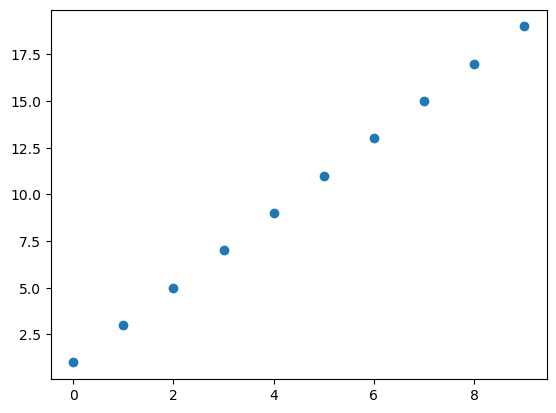

In [16]:
plt.plot(x, y, 'o');

In [17]:
# Dane wejściowe dla sklearn są 2-wymiarowe: (próbki == 10 x cechy == 1)
X = x[:, np.newaxis]
print(X)
print(y)

[[0]
 [1]
 [2]
 [3]
 [4]
 [5]
 [6]
 [7]
 [8]
 [9]]
[ 1  3  5  7  9 11 13 15 17 19]


In [18]:
# Dopasuj model do naszych danych
model.fit(X, y)

LinearRegression()

In [19]:
# Podkreślenie na końcu wskazuje na parametr dopasowany.
print(model.coef_)
print(model.intercept_)

[2.]
1.0000000000000053


Model znalazł linię o nachyleniu 2 i przecięciu 1, zgodnie z oczekiwaniami.

## Uczenie nadzorowane: Klasyfikacja i regresja

W **uczeniu nadzorowanym** dysponujemy zbiorem danych składającym się zarówno z cech, jak i etykiet. Zadaniem jest skonstruowanie estymatora, który potrafi przewidzieć etykietę obiektu na podstawie zestawu jego cech. Relatywnie prostym przykładem jest przewidywanie gatunku irysa na podstawie zestawu pomiarów jego kwiatu. Jest to stosunkowo proste zadanie. Bardziej złożone przykłady obejmują:

- na podstawie wielokolorowego obrazu obiektu uzyskanego za pomocą teleskopu, określenie, czy obiekt jest gwiazdą, kwazarem czy galaktyką;
- na podstawie zdjęcia osoby, identyfikacja tej osoby;
- na podstawie listy filmów obejrzanych przez osobę i jej osobistych ocen, zaproponowanie listy filmów, które mogłyby jej się spodobać (tak zwane *systemy rekomendacyjne*; słynnym przykładem jest [Netflix Prize](http://en.wikipedia.org/wiki/Netflix_prize)).

Wspólną cechą tych zadań jest to, że dla każdego obiektu istnieją jedna lub więcej nieznanych wielkości, które należy określić na podstawie innych zaobserwowanych wielkości.

Uczenie nadzorowane dzieli się dalej na dwie kategorie: **klasyfikację** i **regresję**.  
W klasyfikacji etykieta jest **dyskretna**, natomiast w regresji etykieta jest **ciągła**.  
Na przykład w astronomii zadanie określenia, czy dany obiekt to gwiazda, galaktyka czy kwazar, jest problemem klasyfikacji: etykieta pochodzi z trzech odrębnych kategorii. Z kolei, jeśli chcielibyśmy oszacować wiek obiektu na podstawie takich obserwacji, byłby to problem regresji, ponieważ etykieta (wiek) jest wielkością ciągłą.

### Przykład klasyfikacji

Algorytm k-najbliższych sąsiadów k-NN jest jedną z najprostszych strategii uczenia: dla nowej, nieznanej obserwacji wyszukuje w bazie referencyjnej obiekty o najbardziej zbliżonych cechach i przypisuje dominującą klasę.

Wypróbujmy to na naszym problemie klasyfikacji irysów:

In [20]:
from sklearn import neighbors, datasets

iris = datasets.load_iris()
X, y = iris.data, iris.target

# tworzenie modelu
knn = neighbors.KNeighborsClassifier(n_neighbors=5)

# dopasowanie
knn.fit(X, y)

# Jakiego rodzaju irys ma działki kielicha o wymiarach 3 cm x 5 cm
# i płatki korony o wymiarach 4 cm x 2 cm?
# Wywołajmy metodę "predict":
result = knn.predict([[3, 5, 4, 2],])

print(iris.target_names[result])

['versicolor']


Możesz również dokonać probabilistycznych predykcji:

In [21]:
knn.predict_proba([[3, 5, 4, 2],])

array([[0. , 0.8, 0.2]])

---

#### Ćwiczenie

Użyj innego estymatora do tego samego problemu: `sklearn.svm.SVC`.

*Zauważ, że nie musisz wiedzieć, czym on jest, aby go użyć. W tym ćwiczeniu po prostu testujemy interfe

Uwaga: Algorytm SVC nie obsługuje bezpośrednio polecenia .predict_proba(). Można go wykorzytać jeśli, ustawimy  svc = SVC(probability=True), wynik jednak może być niespójny z wynikiem uzyskanym bezpośrednio z algorytmu.js.*

In [22]:
from sklearn.svm import SVC

---

### Przykład regresji

Jednym z najprostszych problemów regresji jest dopasowanie linii do danych, co pokazano powyżej.  
Scikit-Learn zawiera również bardziej zaawansowane algorytmy regresji.

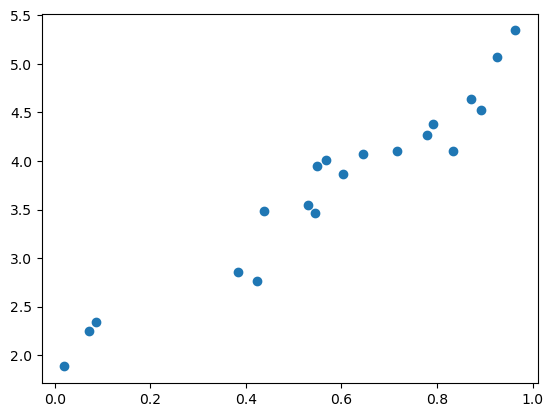

In [24]:
# Utwórz prostą próbkę danych
import numpy as np
np.random.seed(0)
X = np.random.random(size=(20, 1))
y = 3 * X.squeeze() + 2 + np.random.randn(20)/5

# Metoda X.squeeze() usuwa wszystkie wymiary o rozmiarze 1 z tablicy (np. z obiektu numpy.ndarray). 
# Jest to przydatne, gdy chcesz "spłaszczyć" tablicę do mniejszej liczby wymiarów, usuwając osie, które nie wnoszą informacji.

plt.plot(X.squeeze(), y, 'o');

Jak powyżej, możemy narysować linię najlepszego dopasowania:

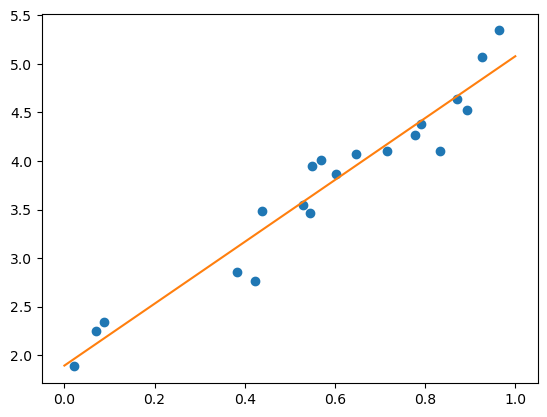

In [25]:
model = LinearRegression()
model.fit(X, y)

# Zwizualizuj dane i przewidywania modelu
X_fit = np.linspace(0, 1, 100)[:, np.newaxis]
y_fit = model.predict(X_fit)

plt.plot(X.squeeze(), y, 'o')
plt.plot(X_fit.squeeze(), y_fit);

Scikit-learn posiada również bardziej zaawansowane modele, które potrafią reagować na bardziej subtelne cechy danych:

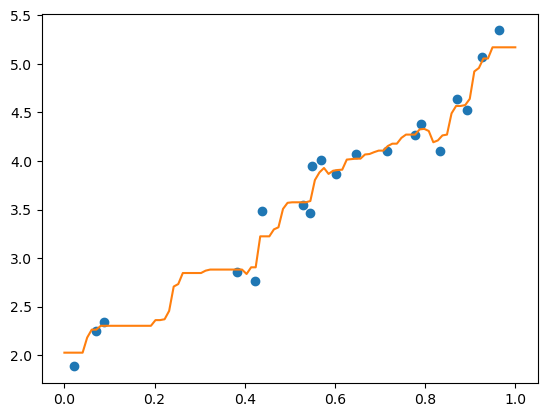

In [26]:
# Wykorzystaj Random Forest
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X, y)

# Zwizualizuj dane i przewidywania modelu
X_fit = np.linspace(0, 1, 100)[:, np.newaxis]
y_fit = model.predict(X_fit)

plt.plot(X.squeeze(), y, 'o')
plt.plot(X_fit.squeeze(), y_fit);

To, czy którykolwiek z tych modeli jest „dobrym” dopasowaniem, zależy od wielu czynników; szczegóły dotyczące wyboru modelu omówimy to później.

---

#### Ćwiczenie

Zbadaj obiekt `RandomForestRegressor` za pomocą funkcji pomocy w IPythonie.  
Jakie argumenty są dostępne dla `RandomForestRegressor`?  
Jak zmienia się powyższy wykres, jeśli zmienisz te argumenty(np. n_estimators=2)?

Te argumenty na poziomie klasy są znane jako *hiperpaametry*..

---

---

#### Ćwiczenie

Co trzeba zrobić, aby algorytmu Random Forest wykorzystać do poprzedniego zadania?

Zrób to.

Podpowiedź: https://scikit-learn.org/dev/api/sklearn.ensemble.html 

---

## Uczenie nienadzorowane: Redukcja wymiarów i klasteryzacja

**Uczenie nienadzorowane** zajmuje się innym rodzajem problemów. W tym przypadku dane nie mają etykiet, a nas interesuje znajdowanie podobieństw między obiektami. W pewnym sensie można myśleć o uczeniu nienadzorowanym jako sposobie odkrywania etykiet na podstawie samych danych. Uczenie nienadzorowane obejmuje takie zadania jak *redukcja wymiarów*, *klasteryzacja* czy *oszacowanie gęstości*. 

Na przykład w przypadku danych irysów omówionych wcześniej możemy użyć metod nienadzorowanych do określenia kombinacji pomiarów, które najlepiej przedstawiają strukturę danych. Jak zobaczymy poniżej, taka projekcja danych może być użyta do wizualizacji czterowymiarowego zbioru danych w dwóch wymiarach. 

Bardziej złożone problemy uczenia nienadzorowanego to:
- na podstawie szczegółowych obserwacji odległych galaktyk określenie, które cechy lub ich kombinacje najlepiej podsumowują informacje;
- na podstawie mieszanki dwóch źródeł dźwięku (na przykład osoba mówiąca na tle muzyki) oddzielenie tych dwóch źródeł (problem nazywany [ślepym rozdzielaniem źródeł](http://en.wikipedia.org/wiki/Blind_signal_separation));
- na podstawie wideo wyodrębnienie poruszającego się obiektu i jego kategoryzacja w odniesieniu do innych zaobserwowanych poruszających się obiektów.

Czasami oba rodzaje uczenia mogą być połączone: na przykład uczenie nienadzorowane może być użyte do znalezienia użytecznych cech w heterogenicznych danych, a następnie te cechy mogą być wykorzystane w ramach uczenia nadzorowanego.

### Redukcja wymiarów: PCA

Analiza głównych składowych (PCA, ang. *Principal Component Analysis*) to technika redukcji wymiarów, która pozwala znaleźć kombinacje zmiennych wyjaśniające największą wariancję.

Rozważmy zbiór danych irysów. Nie można go zwizualizować na pojedynczym wykresie 2D, ponieważ zawiera 4 cechy. Zamierzamy wyodrębnić 2 kombinacje wymiarów działek kielicha (*sepal*) i płatków korony (*petal*), aby go zwizualizować:

In [27]:
X, y = iris.data, iris.target

from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit(X)
X_reduced = pca.transform(X)

print("Oryginalny wymiar danych:", X.shape)
print("Zredukowany wymiar danych:", X_reduced.shape)

Oryginalny wymiar danych: (150, 4)
Zredukowany wymiar danych: (150, 2)


Parametr n_components=0.95 oznacza, że PCA wybiera minimalną liczbę głównych składowych (Principal Components), które wyjaśniają co najmniej 95% wariancji w danych. W tm przypadku okazało się, że wystarczą 2 składowe.

Poszczególne składowe obliczeń:
[[ 0.36138659 -0.08452251  0.85667061  0.3582892 ]
 [ 0.65658877  0.73016143 -0.17337266 -0.07548102]]

Znaczenie dwóch składowych:
0.361 x sepal length (cm) + -0.085 x sepal width (cm) + 0.857 x petal length (cm) + 0.358 x petal width (cm)
0.657 x sepal length (cm) + 0.730 x sepal width (cm) + -0.173 x petal length (cm) + -0.075 x petal width (cm)


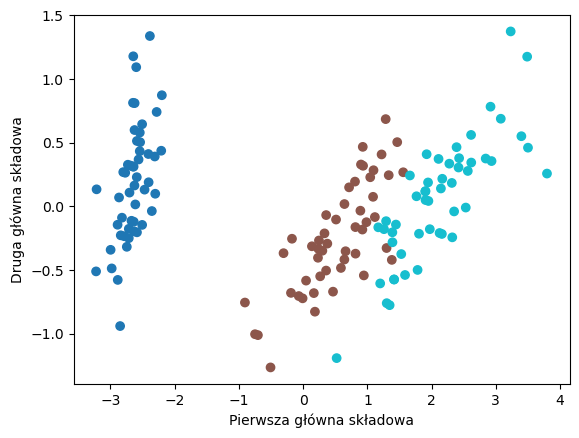

In [28]:
import pylab as plt
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap='tab10')
plt.xlabel("Pierwsza główna składowa")
plt.ylabel("Druga główna składowa")

print("Poszczególne składowe obliczeń:")
print(pca.components_)
print()
print("Znaczenie dwóch składowych:")
for component in pca.components_:
    print(" + ".join("%.3f x %s" % (value, name)
                     for value, name in zip(component,
                                            iris.feature_names)))

### Klasteryzacja: K-means

Klasteryzacja grupuje obserwacje, które są jednorodne względem określonego kryterium, znajdując „klastry” w danych.

Należy zauważyć, że te klastry ujawnią istotną ukrytą strukturę danych tylko wtedy, gdy zastosowane kryterium odpowiednio ją uwidoc

UWAGA: 
* może wystąpić błąd w .fit: AttributeError: 'NoneType' object has no attribute 'split'
* trzeba wtedy aktualizować threadpoolctl do wersji >3zni.

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


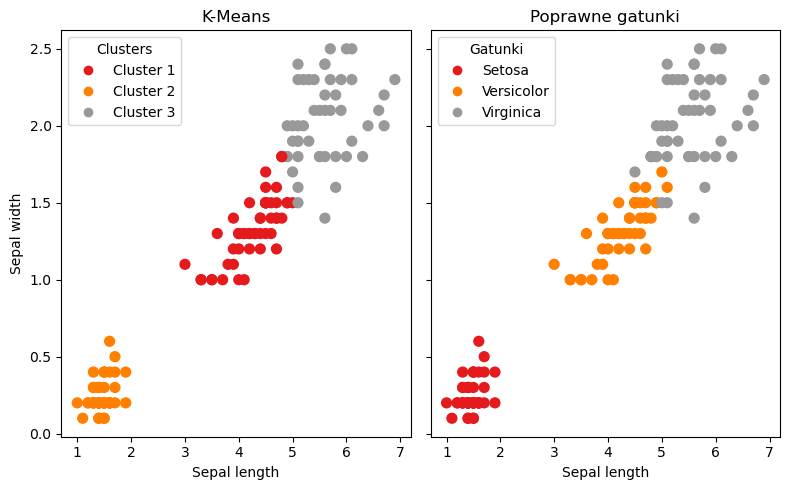

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

# Załaduj dane Iris
iris = load_iris()
X = iris.data[:, 2:4]  # Używamy cech: długość i szerokość płatka
y = iris.target  # Rzeczywiste etykiety klas

# Klasteryzacja K-Means
k_means = KMeans(n_clusters=3, random_state=0)
k_means.fit(X)
y_pred = k_means.predict(X)

# Mapowanie klastrów na nazwy
cluster_names = {0: "Cluster 1", 1: "Cluster 2", 2: "Cluster 3"}
species_names = {0: "Setosa", 1: "Versicolor", 2: "Virginica"}

# Rysowanie wykresów obok siebie
fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharex=True, sharey=True)

# Wykres 1: Klasteryzacja K-Means
scatter1 = axes[0].scatter(X[:, 0], X[:, 1], c=y_pred, cmap='Set1', s=50)
axes[0].set_title("K-Means")
axes[0].set_xlabel("Sepal length")
axes[0].set_ylabel("Sepal width")
handles1, labels1 = scatter1.legend_elements()
legend_labels1 = [cluster_names[int(label.replace('$\\mathdefault{', '').replace('}$', ''))] for label in labels1]
axes[0].legend(handles1, legend_labels1, title="Clusters", loc="best")

# Wykres 2: Rzeczywiste gatunki
scatter2 = axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap='Set1', s=50)
axes[1].set_title("Poprawne gatunki")
axes[1].set_xlabel("Sepal length")
handles2, labels2 = scatter2.legend_elements()
legend_labels2 = [species_names[int(label.replace('$\\mathdefault{', '').replace('}$', ''))] for label in labels2]
axes[1].legend(handles2, legend_labels2, title="Gatunki", loc="best")

# Wyświetlenie wykresów
plt.tight_layout()
plt.show()

In [30]:
import warnings
warnings.filterwarnings("ignore")

W powyższym przykładzie mogliśmy najpierw zrobić PCA, a potem klasteryzację na podstawie tych dwóch składowych.

### Podsumowanie: Estymatory w Scikit-learn

Scikit-learn dąży do zapewnienia jednolitego interfejsu we wszystkich metodach. Poniżej znajdują się przykłady. Dla obiektu *estimator* Scikit-learn o nazwie `model` dostępne są następujące metody:

- Dostępne w **wszystkich estymatorach**:
  + `model.fit()`: Dopasowuje dane treningowe. W przypadku uczenia nadzorowanego metoda akceptuje dwa argumenty: dane `X` i etykiety `y` (np. `model.fit(X, y)`).  
    W przypadku uczenia nienadzorowanego metoda przyjmuje tylko jeden argument, dane `X` (np. `model.fit(X)`).

- Dostępne w **estymatorach nadzorowanych**:
  + `model.predict()`: Mając wytrenowany model, przewiduje etykietę dla nowego zestawu danych.  
    Ta metoda akceptuje jeden argument, nowe dane `X_new` (np. `model.predict(X_new)`), i zwraca przewidziane etykiety dla każdego obiektu w tablicy.
  + `model.predict_proba()`: W problemach klasyfikacji niektóre estymatory oferują tę metodę, która zwraca prawdopodobieństwo przypisania każdej nowej obserwacji do poszczególnych kategorii.  
    W tym przypadku etykieta z najwyższym prawdopodobieństwem jest zwracana przez `model.predict()`.
  + `model.score()`: W problemach klasyfikacji lub regresji większość (wszystkie?) estymatorów implementuje metodę `score`.  
    Wyniki są w przedziale od 0 do 1, gdzie wyższy wynik oznacza lepsze dopasowanie.

- Dostępne w **estymatorach nienadzorowanych**:
  + `model.predict()`: Przewiduje etykiety w algorytmach klasteryzacji.
  + `model.transform()`: Mając model nienadzorowany, przekształca nowe dane na nową podstawę.  
    Ta metoda akceptuje jeden argument `X_new` i zwraca nową reprezentację danych opartą na modelu nienadzorowanym.
  + `model.fit_transform()`: Niektóre estymatory implementują tę metodę, która efektywniej wykonuje dopasowanie i przekształcenie na tych samych danych wejściowych.

## Walidacja modelu

Istotnym elementemodeligo jest **walidacja modelu**, czyli określenie, jak dobrze model będzie generalizował z danych treningowych na przyszłe, nieoznaczone dane. Przyjrzyjmy się przykładowi z użyciem klasyfikatora *najbliższego sąsiada* (*nearest neighbor classifier*). Jest to bardzo prosty klasyfikator: po prostu przechowuje wszystkie dane treningowe, a dla dowolnego nieznanego punktu zwraca etykietę najbliższego punktu treningowego.

W przypadku danych irysów bardzo łatwo zwraca poprawną predykcję dla każdego z punktów wejściowych:

In [31]:
from sklearn.neighbors import KNeighborsClassifier
X, y = iris.data, iris.target
clf = KNeighborsClassifier(n_neighbors=1)
clf.fit(X, y)
y_pred = clf.predict(X)
print(np.all(y == y_pred))

True


Bardziej przydatnym sposobem analizowania wyników jest spojrzenie na **macierz pomyłek** (*confusion matrix*), czyli macierz pokazującą częstotliwość występowania danych wejściowych i wyjściowych:

In [32]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y, y_pred))

[[50  0  0]
 [ 0 50  0]
 [ 0  0 50]]


Dla każdej klasy wszystkie 50 próbek treningowych zostało poprawnie zidentyfikowanych. Ale to **nie oznacza, że nasz model jest idealny!** W szczególności taki model bardzo słabo generalizuje na nowe dane. Możemy to zasymulować, dzieląc nasze dane na *zbiór treningowy* i *zbiór testowy*. Scikit-learn zawiera wygodne funkcje, które to umożliwiają:

In [33]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3)
clf.fit(Xtrain, ytrain)
ypred = clf.predict(Xtest)
print(confusion_matrix(ytest, ypred))

[[15  0  0]
 [ 0 15  0]
 [ 0  2 13]]


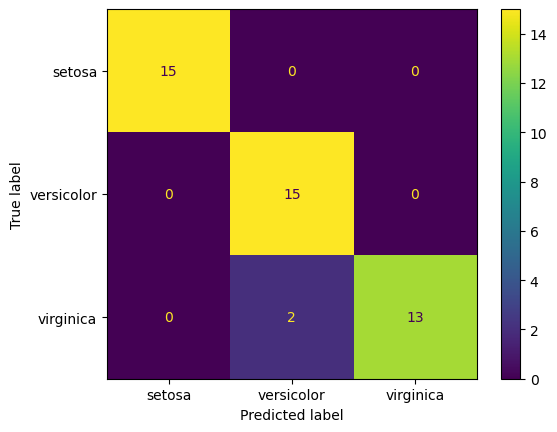

In [34]:
# Macierz pomyłek
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(ytest, ypred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()

To daje lepszy obraz rzeczywistej wydajności naszego klasyfikatora: najwyraźniej występuje pewne zamieszanie między drugą a trzecią klasą, co można przewidzieć na podstawie wcześniejszej analizy danych.

Dlatego właśnie **szczególnie ważne** jest stosowanie podziału na zbiór treningowy i testowy podczas oceny model Można też zrealizować bardziej wyrafinowany sposób podejśćia, jak **walidacja krzyżowa*i.

Dokładności w poszczególnych foldach: [0.93333333 0.96666667 1.         0.96666667 0.93333333]
Średnia dokładność: 0.96


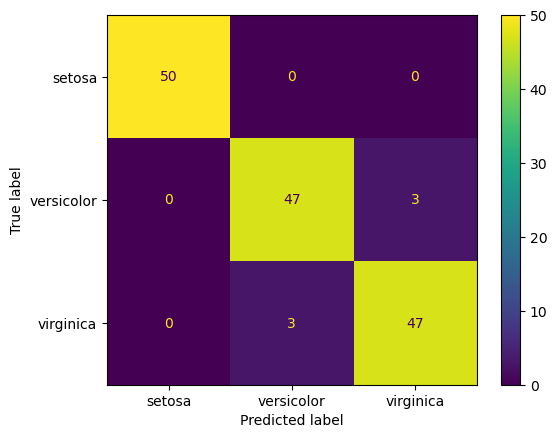

In [35]:
from sklearn.model_selection import cross_val_predict, cross_val_score, StratifiedKFold

# Konfiguracja walidacji krzyżowej
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=200)

# Walidacja krzyżowa (5-fold)
scores = cross_val_score(clf, X, y, cv=cv) 
#Uwaga, można tez wskazać np. cv = 5, ale wtedy nie zapewnia się tego samego podziału w innych miejscach

# Wyświetlenie wyników walidacji krzyżowej
print("Dokładności w poszczególnych foldach:", scores)
print("Średnia dokładność:", np.mean(scores))

# Dodatkowa analiza: macierz pomyłek
from sklearn.model_selection import cross_val_predict
ypred = cross_val_predict(clf, X, y, cv=cv)

# Macierz pomyłek
cm = confusion_matrix(y, ypred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()

## Schemat blokowy: Jak wybrać estymator?

To schemat blokowy stworzony przez Scikit-Leana, który stanowi świetne podsumowanie dotyczące wyboru algorytmu w różnych sytuacjac:!

![Schemat blokowy](.\\Images\\schemat.png)

## Źródła

* https://scikit-learn.org/dev/user_guide.html
* http://scikit-learn.org/dev/_static/ml_map.png

## Zadanie

Wykorzystując dane "Dataset - Bikes.xlsx" stwórz model predykcyjny.

Odpowiedz na pytanie, które z cech są najważniejsze w modelu.

Podpowiedzi:
* czy potrzebujesz wszystkich pól?
* zapoznaj się z funkcją get_dummies z pandas.

In [36]:
## Pozwiązanie (początek)

In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

In [38]:
# Wczytanie danych z pliku
df = pd.read_excel('./Data/Dataset - Bikes.xlsx', sheet_name='Table Analysis Tools Sample')

In [39]:
# Przygotowanie danych
df = df.drop(columns=['ID'])  # Usunięcie kolumny ID
df_encoded = pd.get_dummies(df, drop_first=True)  # Kodowanie zmiennych kategorycznych

In [40]:
# Dalej trzeba już samemu :)